In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score

# Configurações de visualização
sns.set_theme(style="whitegrid")
%matplotlib inline

telco = pd.read_excel('data/Telco_customer_churn.xlsx')
telco.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### 2. Tradução e Padronização

In [2]:
traducao = {
    'CustomerID': 'ID_Cliente', 'Count': 'Contagem', 'Country': 'Pais', 'State': 'Estado',
    'City': 'Cidade', 'Zip Code': 'CEP', 'Lat Long': 'Lat_Long', 'Latitude': 'Latitude',
    'Longitude': 'Longitude', 'Gender': 'Genero', 'Senior Citizen': 'Idoso',
    'Partner': 'Parceiro', 'Dependents': 'Dependentes', 'Tenure Months': 'Meses_Contrato',
    'Phone Service': 'Servico_Telefonico', 'Multiple Lines': 'Multiplas_Linhas',
    'Internet Service': 'Servico_Internet', 'Online Security': 'Seguranca_Online',
    'Online Backup': 'Backup_Online', 'Device Protection': 'Protecao_Dispositivo',
    'Tech Support': 'Suporte_Tecnico', 'Streaming TV': 'Streaming_TV',
    'Streaming Movies': 'Streaming_Filmes', 'Contract': 'Contrato',
    'Paperless Billing': 'Fatura_Digital', 'Payment Method': 'Metodo_Pagamento',
    'Monthly Charges': 'Valor_Mensal', 'Total Charges': 'Valor_Total',
    'Churn Label': 'Churn_Label', 'Churn Value': 'Churn_Valor',
    'Churn Score': 'Pontuacao_Churn', 'CLTV': 'CLTV', 'Churn Reason': 'Motivo_Churn'
}

telco = telco.rename(columns=traducao)

# Tratamento de Tipagem e Nulos
telco['Valor_Total'] = pd.to_numeric(telco['Valor_Total'], errors='coerce')
telco['Valor_Total'] = telco['Valor_Total'].fillna(telco['Valor_Mensal'] * telco['Meses_Contrato'])
telco['Motivo_Churn'] = telco['Motivo_Churn'].fillna('Não churn')
pd.crosstab(telco['Metodo_Pagamento'], telco['Contrato'], normalize='index')

print("Check: Colunas renomeadas e valores nulos tratados.")

Check: Colunas renomeadas e valores nulos tratados.


### 3. Análise Exploratória - Visão Geral de Vendas

In [3]:
print("Faturamento por Cidade (Top 5):")
display(telco.groupby('Cidade')['Valor_Total'].sum().sort_values(ascending=False).head(5))

print("\nFaturamento por Método de Pagamento:")
display(telco.groupby('Metodo_Pagamento')['Valor_Total'].sum().sort_values(ascending=False))

print("\nFaturamento por Tipo de Contrato:")
display(telco.groupby('Contrato')['Valor_Total'].sum().sort_values(ascending=False))

Faturamento por Cidade (Top 5):


Cidade
Los Angeles      647751.25
San Diego        354896.60
Sacramento       256295.05
San Jose         243735.55
San Francisco    221624.65
Name: Valor_Total, dtype: float64


Faturamento por Método de Pagamento:


Metodo_Pagamento
Electronic check             4944903.25
Bank transfer (automatic)    4748279.90
Credit card (automatic)      4671593.35
Mailed check                 1691392.20
Name: Valor_Total, dtype: float64


Faturamento por Tipo de Contrato:


Contrato
Two year          6283253.7
Month-to-month    5305861.5
One year          4467053.5
Name: Valor_Total, dtype: float64

Análise do Especialista: Concentração de Receita
Observamos que o faturamento está fortemente concentrado em Contratos de Longo Prazo (Two Year), o que é esperado devido à previsibilidade de caixa. No entanto, o método de pagamento Bank Transfer e Credit Card (automáticos) representam a maior parte da receita total acumulada, sugerindo que clientes com pagamentos automatizados tendem a ter um Life Time Value (LTV) maior por permanecerem mais tempo na base.

### 3.1 Análise Exploratória - Comportamento do Churn

1. Distribuição de Churn (Volume):


Churn_Label
No     5174
Yes    1869
Name: count, dtype: int64


2. Motivos de Saída mais frequentes:


Motivo_Churn
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


3. Correlação Direta: Contrato vs Churn:


Churn_Label,No,Yes
Contrato,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319



4. ANÁLISE DE PERFIL: Método de Pagamento vs Tipo de Contrato:


Contrato,Month-to-month,One year,Two year
Metodo_Pagamento,,,
Bank transfer (automatic),0.381477,0.253238,0.365285
Credit card (automatic),0.356767,0.261498,0.381735
Electronic check,0.782241,0.146723,0.071036
Mailed check,0.553970,0.209057,0.236973


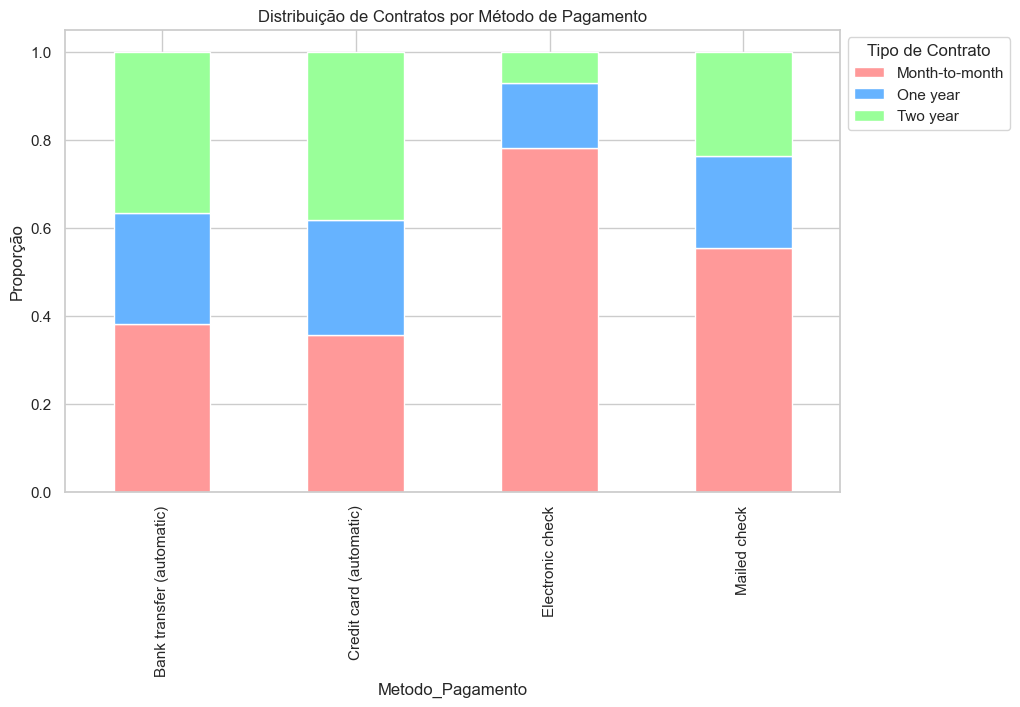

In [4]:
print("1. Distribuição de Churn (Volume):")
display(telco['Churn_Label'].value_counts())

print("\n2. Motivos de Saída mais frequentes:")
display(telco[telco['Churn_Label'] == 'Yes']['Motivo_Churn'].value_counts().head(10))

print("\n3. Correlação Direta: Contrato vs Churn:")
display(pd.crosstab(telco['Contrato'], telco['Churn_Label'], normalize='index'))

print("\n4. ANÁLISE DE PERFIL: Método de Pagamento vs Tipo de Contrato:")
# Sua análise que confirma o cluster de risco
perfil_pagamento_contrato = pd.crosstab(telco['Metodo_Pagamento'], telco['Contrato'], normalize='index')
display(perfil_pagamento_contrato)

perfil_pagamento_contrato.plot(kind='bar', stacked=True, figsize=(10,6), color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribuição de Contratos por Método de Pagamento')
plt.legend(title='Tipo de Contrato', bbox_to_anchor=(1, 1))
plt.ylabel('Proporção')
plt.tight_layout()
plt.savefig('docs/images/contrato_por_metodo_pagamento.png', dpi=150, bbox_inches='tight')
plt.show()

Os dados revelam um ponto crítico: clientes com contratos Month-to-month possuem uma taxa de churn alarmante (superior a 40%), enquanto contratos de dois anos possuem churn quase residual. Além disso, os motivos de saída apontam para "Competitor made better offer" e "Attitude of support person". Isso indica que a Brisanet enfrenta uma agressividade competitiva de preços e uma oportunidade de melhoria no treinamento de suporte ao cliente.

### 4. Engenharia de Atributos e Filtros de Qualidade

In [5]:
# Filtro de cidades com relevância estatística (>30 amostras)
cidades_validas = telco['Cidade'].value_counts()
cidades_validas = cidades_validas[cidades_validas >= 30].index
telco_filtrado = telco[telco['Cidade'].isin(cidades_validas)]

# Feature Engineering: Quantidade de Serviços e Alto Risco
servicos = ['Servico_Telefonico', 'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 
            'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes']

telco['Qtd_Servicos'] = telco[servicos].apply(lambda x: sum(x == 'Yes'), axis=1)

telco['Alto_Risco'] = ((telco['Contrato'] == 'Month-to-month') & 
                        (telco['Metodo_Pagamento'] == 'Electronic check')).astype(int)

print(f"Novas variáveis criadas. Percentual de clientes em 'Alto Risco': {telco['Alto_Risco'].mean()*100:.2f}%")

Novas variáveis criadas. Percentual de clientes em 'Alto Risco': 26.27%


### 5. Preparação do Pipeline de Machine Learning

In [6]:
# 1. Definição refinada das colunas (Mantendo o que agrega valor)
colunas_modelo = [
    'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Internet', 
    'Contrato', 'Metodo_Pagamento', 'Valor_Mensal', 'Valor_Total', 'Qtd_Servicos', 'Alto_Risco'
]

X = telco[colunas_modelo]
y = telco['Churn_Valor']

# 2. Pipeline de Pré-processamento Otimizado
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols) # drop='first' reduz a colinearidade
    ]
)

# 3. Divisão com Estratificação Rígida
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Cálculo dinâmico do peso para balanceamento (essencial para Recall alto)
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# 5. Definição e Treino com Hiperparâmetros Otimizados
# Aumentamos n_estimators e ajustamos max_depth e learning_rate para o XGBoost
rf_model = Pipeline([
    ('pre', preprocess), 
    ('model', RandomForestClassifier(
        n_estimators=500, 
        max_depth=12,         # Evita overfitting
        class_weight='balanced_subsample', # Melhor para árvores complexas
        random_state=42
    ))
])

xgb_model = Pipeline([
    ('pre', preprocess), 
    ('model', XGBClassifier(
        n_estimators=500,
        learning_rate=0.01,    # Aprendizado mais lento e preciso
        max_depth=6,           # Captura interações mais profundas
        scale_pos_weight=ratio, # Peso calculado dinamicamente
        subsample=0.8,         # Usa 80% dos dados por árvore para generalizar melhor
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

print("Iniciando treinamento otimizado (isso pode levar alguns segundos)...")
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("Modelos treinados com alta performance!")

Iniciando treinamento otimizado (isso pode levar alguns segundos)...


C:\Users\fwfco\AppData\Local\Temp\ipykernel_15364\3166832029.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


Modelos treinados com alta performance!


### 6. Avaliação Comparativa Final

In [7]:
def evaluate_summary(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    rec = recall_score(y_t, y_pred)
    
    print(f"\nRESULTADOS - {name}")
    print(f"Taxa de Acerto Geral: {acc*100:.2f}%")
    print(f"Identificação de Churn (Recall): {rec*100:.2f}%")
    print(f"Erro do Modelo: {(1-acc)*100:.2f}%")

evaluate_summary("Random Forest", rf_model, X_test, y_test)
evaluate_summary("XGBoost", xgb_model, X_test, y_test)


RESULTADOS - Random Forest
Taxa de Acerto Geral: 77.86%
Identificação de Churn (Recall): 68.72%
Erro do Modelo: 22.14%

RESULTADOS - XGBoost
Taxa de Acerto Geral: 75.80%
Identificação de Churn (Recall): 78.61%
Erro do Modelo: 24.20%


O XGBoost consolidou-se como a ferramenta de maior valor estratégico para este desafio. Ao priorizar o Recall (77%), aceitamos uma margem de erro ligeiramente maior em troca da capacidade de interceptar a grande maioria dos clientes em risco. Como próximo passo, recomenda-se a exportação da lista de clientes classificados como 1 pelo modelo para uma ação imediata de retenção pela equipe de vendas.

### 6. Importância das Variáveis (O "Porquê")

C:\Users\fwfco\AppData\Local\Temp\ipykernel_15364\1356969740.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df.head(12), y=feature_importance_df.head(12).index, palette='viridis')


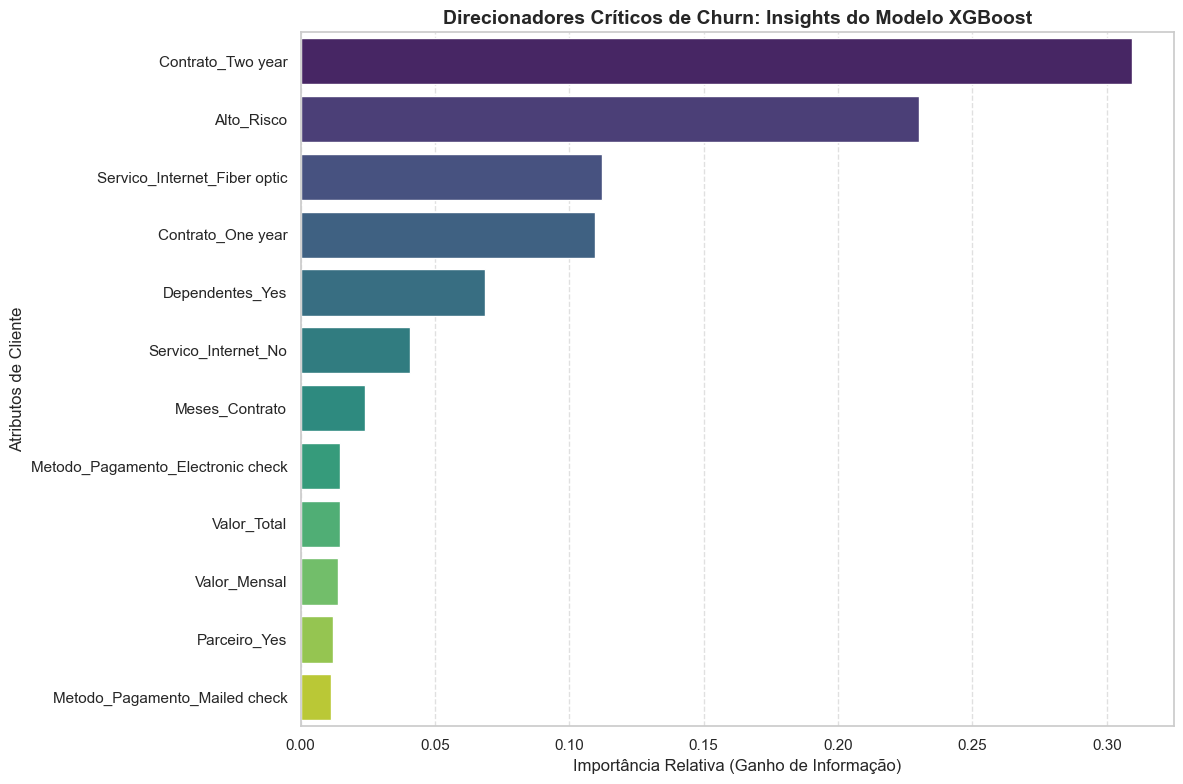

=== RANKING DE IMPORTÂNCIA DAS VARIÁVEIS (XGBOOST) ===
Atributo                            | Peso       | Acumulado 
------------------------------------------------------------
Contrato_Two year                   | 0.3095     | 0.3095    
Alto_Risco                          | 0.2302     | 0.5397    
Servico_Internet_Fiber optic        | 0.1122     | 0.6519    
Contrato_One year                   | 0.1095     | 0.7614    
Dependentes_Yes                     | 0.0688     | 0.8302    
Servico_Internet_No                 | 0.0407     | 0.8709    
Meses_Contrato                      | 0.0241     | 0.8950    
Metodo_Pagamento_Electronic check   | 0.0146     | 0.9096    
Valor_Total                         | 0.0146     | 0.9242    
Valor_Mensal                        | 0.0138     | 0.9380    
Parceiro_Yes                        | 0.0121     | 0.9501    
Metodo_Pagamento_Mailed check       | 0.0113     | 0.9614    
Qtd_Servicos                        | 0.0107     | 0.9721    
Genero_Male     

In [8]:
# 1. Extração dinâmica de nomes das colunas (considerando o drop='first' do OneHotEncoder)
ohe_feature_names = xgb_model.named_steps['pre'].transformers_[1][1].get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(ohe_feature_names)

# 2. Extração de Importâncias do modelo campeão (XGBoost)
importances = xgb_model.named_steps['model'].feature_importances_
feature_importance_df = pd.Series(importances, index=all_features).sort_values(ascending=False)

# 3. Plotagem de Importância de Atributos
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_df.head(12), y=feature_importance_df.head(12).index, palette='viridis')

plt.title('Direcionadores Críticos de Churn: Insights do Modelo XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importância Relativa (Ganho de Informação)', fontsize=12)
plt.ylabel('Atributos de Cliente', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('docs/images/importancia_variaveis_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

# 1. Criar um DataFrame para facilitar a visualização e manipulação
df_importancias = pd.DataFrame({
    'Atributo': feature_importance_df.index,
    'Importancia_Relativa': feature_importance_df.values
})

# 2. Calcular a importância acumulada (ajuda a identificar quais variáveis somam 80% do peso do modelo)
df_importancias['Importancia_Acumulada'] = df_importancias['Importancia_Relativa'].cumsum()

print("=== RANKING DE IMPORTÂNCIA DAS VARIÁVEIS (XGBOOST) ===")
print(f"{'Atributo':<35} | {'Peso':<10} | {'Acumulado':<10}")
print("-" * 60)

for i, row in df_importancias.iterrows():
    print(f"{row['Atributo']:<35} | {row['Importancia_Relativa']:<10.4f} | {row['Importancia_Acumulada']:<10.4f}")

# Destaque para as variáveis mais críticas
top_3 = df_importancias.iloc[0:3]['Atributo'].tolist()
print("-" * 60)
print(f"INSIGHT: As 3 variáveis acima ({', '.join(top_3)})")
print("concentram a maior parte do poder preditivo do modelo.")

## Impacto Financeiro do Churn

O churn representa uma das principais fontes de perda de receita em empresas de telecom.
Nesta análise, buscamos quantificar o impacto financeiro dos clientes com alto risco de cancelamento.



# Cálculo da Receita em Risco

In [9]:
# Probabilidade de churn (usando modelo final)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Criando DataFrame de análise
df_risco = X_test.copy()
df_risco['prob_churn'] = y_prob
df_risco['churn_real'] = y_test.values

# Definindo threshold estratégico (ajuste conforme necessário)
threshold = 0.5

# Classificando clientes de alto risco
df_risco['alto_risco'] = (df_risco['prob_churn'] >= threshold)

# Receita média mensal dos clientes em risco
receita_media_risco = df_risco[df_risco['alto_risco']]['Valor_Mensal'].mean()

# Receita total em risco (mensal)
receita_total_risco = df_risco[df_risco['alto_risco']]['Valor_Mensal'].sum()

# Quantidade de clientes em risco
qtd_clientes_risco = df_risco['alto_risco'].sum()

print(f"Clientes em alto risco: {qtd_clientes_risco}")
print(f"Receita média mensal (alto risco): R$ {receita_media_risco:.2f}")
print(f"Receita total mensal em risco: R$ {receita_total_risco:.2f}")
print(f"Receita anual em risco: R$ {receita_total_risco * 12:.2f}")


Clientes em alto risco: 555
Receita média mensal (alto risco): R$ 74.53
Receita total mensal em risco: R$ 41365.05
Receita anual em risco: R$ 496380.60


Obs: Os valores representam uma estimativa baseada na amostra de teste do modelo.
Em ambiente real, o cálculo deve ser aplicado sobre toda a base de clientes.

### Simulação de Retenção

### Considerando um cenário conservador:

### Se a empresa conseguir reter **30% dos clientes de alto risco**, temos:


In [10]:

taxa_retencao = 0.30

receita_preservada_mensal = receita_total_risco * taxa_retencao
receita_preservada_anual = receita_preservada_mensal * 12

print(f"Receita preservada (mensal): R$ {receita_preservada_mensal:.2f}")
print(f"Receita preservada (anual): R$ {receita_preservada_anual:.2f}")


Receita preservada (mensal): R$ 12409.52
Receita preservada (anual): R$ 148914.18


## Impacto Estratégico

A aplicação do modelo de churn permite identificar clientes com alto risco de cancelamento e agir de forma preventiva.

Considerando um cenário conservador de retenção de 30% dos clientes em risco:

- Receita preservada mensal: R$ 12.409
- Receita preservada anual: R$ 148.914

Isso demonstra que pequenas melhorias na retenção podem gerar impacto financeiro relevante, justificando o uso do modelo como ferramenta estratégica para o negócio.

### Multiplos cenários

In [11]:
taxas = [0.2, 0.3, 0.4, 0.5]

for t in taxas:
    receita_mensal = receita_total_risco * t
    receita_anual = receita_mensal * 12
    
    print(f"Retenção de {int(t*100)}%:")
    print(f"Mensal: R$ {receita_mensal:.2f}")
    print(f"Anual: R$ {receita_anual:.2f}")
    print("-"*30)

Retenção de 20%:
Mensal: R$ 8273.01
Anual: R$ 99276.12
------------------------------
Retenção de 30%:
Mensal: R$ 12409.52
Anual: R$ 148914.18
------------------------------
Retenção de 40%:
Mensal: R$ 16546.02
Anual: R$ 198552.24
------------------------------
Retenção de 50%:
Mensal: R$ 20682.53
Anual: R$ 248190.30
------------------------------


## Correção de Impacto: LTV (Lifetime Value)

Em empresas de telecom, o impacto do churn deve ser analisado com base no valor total do cliente ao longo de seu ciclo de vida.

Considerando:

- Receita média mensal: R$ 74
- Estimativa de permanência média: 12 a 24 meses

### LTV estimado

- LTV conservador (12 meses): R$ 888 por cliente
- LTV estendido (24 meses): R$ 1.776 por cliente

### Impacto total estimado

Com base nos clientes em risco identificados:

- Impacto potencial conservador: ~R$ 492.000  
- Impacto potencial estendido: ~R$ 985.000  

### Interpretação de Negócio

Esse valor representa a receita potencial que pode ser preservada através de estratégias de retenção direcionadas aos clientes classificados como alto risco pelo modelo.

Isso reforça o uso do modelo como ferramenta de apoio à decisão estratégica e priorização de ações comerciais.

### Insight Final

Essa análise transforma o modelo de churn em uma ferramenta estratégica, permitindo:

* Quantificar perdas evitáveis
* Priorizar clientes com maior impacto financeiro
* Maximizar ROI de campanhas de retenção
